# 선형회귀 - 보스턴 집값 데이터

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LinearRegression       # 선형모델
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBRegressor

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import mean_squared_error


#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

## 파일 로드

In [2]:
df = pd.read_csv('./data/Boston-house-price-data.csv')

In [3]:
df.columns = df.columns.str.lower()

In [4]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
for i, col in enumerate(df.columns):
    print(f'{col}', df[col].nunique())

crim 504
zn 26
indus 76
chas 2
nox 81
rm 446
age 356
dis 412
rad 9
tax 66
ptratio 46
b 357
lstat 455
medv 229


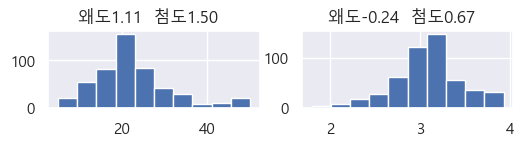

In [8]:
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
df['medv'].hist()
plt.title(f"왜도{df['medv'].skew():.2f}  첨도{df['medv'].kurtosis():.2f}  ")
plt.subplot(1,2,2)
np.log1p(df['medv']).hist()
plt.title(f"왜도{np.log1p(df['medv']).skew():.2f}  첨도{np.log1p(df['medv']).kurtosis():.2f}  ")
plt.show()

In [9]:
df.agg(['skew', 'kurt']).T


,skew,kurt
crim,5.223149,37.130509
zn,2.225666,4.031510
indus,0.295022,-1.233540
chas,3.405904,9.638264
nox,0.729308,-0.064667
rm,0.403612,1.891500
age,-0.598963,-0.967716
dis,1.011781,0.487941
rad,1.004815,-0.867232
tax,0.669956,-1.142408


In [10]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [11]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # imblearn용 파이프라인 필수

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet       # 선형모델
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBRegressor


# 로그 변환 함수 정의 (특정 컬럼만 골라서 변환하도록 설정)
def log_transform_cols(X):
    X_cp = X.copy()
    col_list = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax',
       'ptratio', 'b', 'lstat', 'medv']
    # 컬럼 존재 여부 체크 로직을 넣으면 더 견고해짐
    target_cols = [c for c in col_list if c in X_cp.columns]
    X_cp[target_cols] = np.log1p(X_cp[target_cols])
    return X_cp


def get_pipeline(scaler, model):
    return Pipeline([
    # return Pipeline([
        ('log', FunctionTransformer(log_transform_cols)),
        ('scaler', scaler if scaler else 'passthrough'),
        # k_neighbors를 2로 낮춰 아주 적은 데이터(3개)도 증식 가능하게 함
        # ('smote', SMOTE(random_state=4567, sampling_strategy='auto', k_neighbors=2)),
        ('model', model)
    ])

def train_and_evaluate(X_train_full, X_test, y_train_full, y_test):
    # 모델 및 스케일러 리스트
    scaler_list = [None, StandardScaler()] #, MinMaxScaler(), RobustScaler()]
   
    model_list = [
        LinearRegression(),
        # DecisionTreeRegressor(random_state=42),
        # RandomForestRegressor(random_state=42),
        # XGBRegressor(random_state=42), 
        # LGBMRegressor(random_state=42, verbosity=-1),
        Ridge(random_state=42),
        Lasso(random_state=42),
        ElasticNet(random_state=42)
    ]
       
    
    for scaler in scaler_list:
        for model in model_list:
            model_name = model.__class__.__name__
            scaler_name = scaler.__class__.__name__ if scaler else "None"
            print(f"\n🚀 Testing: {scaler_name} + {model_name}")
            
            pipe = get_pipeline(scaler, model)
            
            pipe.fit(X_train_full, y_train_full)
            
            pred = pipe.predict(X_test)
            mse = mean_squared_error(y_test, pred)
            print(f"MSE: {mse}")
            

In [12]:
X = df.drop('medv', axis=1)
y = df['medv']

X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
train_and_evaluate(X80, X20, y80, y20)


🚀 Testing: None + LinearRegression
MSE: 18.29248895213867

🚀 Testing: None + Ridge
MSE: 18.365532936752135

🚀 Testing: None + Lasso
MSE: 28.528541212800675

🚀 Testing: None + ElasticNet
MSE: 41.448666937441494

🚀 Testing: StandardScaler + LinearRegression
MSE: 18.29248895213871

🚀 Testing: StandardScaler + Ridge
MSE: 18.31550711868383

🚀 Testing: StandardScaler + Lasso
MSE: 22.6270466130552

🚀 Testing: StandardScaler + ElasticNet
MSE: 25.16450285609228


In [14]:
train_and_evaluate(X80, X20, y80, y20)


🚀 Testing: None + LinearRegression
MSE: 18.29248895213867

🚀 Testing: None + Ridge
MSE: 18.365532936752135

🚀 Testing: None + Lasso
MSE: 28.528541212800675

🚀 Testing: None + ElasticNet
MSE: 41.448666937441494

🚀 Testing: StandardScaler + LinearRegression
MSE: 18.29248895213871

🚀 Testing: StandardScaler + Ridge
MSE: 18.31550711868383

🚀 Testing: StandardScaler + Lasso
MSE: 22.6270466130552

🚀 Testing: StandardScaler + ElasticNet
MSE: 25.16450285609228


In [15]:
from sklearn.linear_model import LinearRegression 
lm = LinearRegression()
lm.fit(X80, y80)
pred = lm.predict(X20)
mse = mean_squared_error(y20, pred)

print(f"MSE: {mse}")


MSE: 24.291119474973538


In [16]:
# log 변환
train_and_evaluate(X80, X20, y80, y20)


🚀 Testing: None + LinearRegression
MSE: 18.29248895213867

🚀 Testing: None + Ridge
MSE: 18.365532936752135

🚀 Testing: None + Lasso
MSE: 28.528541212800675

🚀 Testing: None + ElasticNet
MSE: 41.448666937441494

🚀 Testing: StandardScaler + LinearRegression
MSE: 18.29248895213871

🚀 Testing: StandardScaler + Ridge
MSE: 18.31550711868383

🚀 Testing: StandardScaler + Lasso
MSE: 22.6270466130552

🚀 Testing: StandardScaler + ElasticNet
MSE: 25.16450285609228


In [17]:
df['tax'].unique()

array([296., 242., 222., 311., 307., 279., 252., 233., 243., 469., 226.,
       313., 256., 284., 216., 337., 345., 305., 398., 281., 247., 270.,
       276., 384., 432., 188., 437., 403., 193., 265., 255., 329., 402.,
       348., 224., 277., 300., 330., 315., 244., 264., 223., 254., 198.,
       285., 241., 293., 245., 289., 358., 304., 287., 430., 422., 370.,
       352., 351., 280., 335., 411., 187., 334., 666., 711., 391., 273.])

In [18]:
df['rad'].unique()

array([ 1,  2,  3,  5,  4,  8,  6,  7, 24])

In [19]:
df.loc[df['rad']==24,:]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
356,8.98296,0.0,18.1,1,0.770,6.212,97.4,2.1222,24,666.0,20.2,377.73,17.60,17.8
357,3.84970,0.0,18.1,1,0.770,6.395,91.0,2.5052,24,666.0,20.2,391.34,13.27,21.7
358,5.20177,0.0,18.1,1,0.770,6.127,83.4,2.7227,24,666.0,20.2,395.43,11.48,22.7
359,4.26131,0.0,18.1,0,0.770,6.112,81.3,2.5091,24,666.0,20.2,390.74,12.67,22.6
360,4.54192,0.0,18.1,0,0.770,6.398,88.0,2.5182,24,666.0,20.2,374.56,7.79,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,2.81838,0.0,18.1,0,0.532,5.762,40.3,4.0983,24,666.0,20.2,392.92,10.42,21.8
484,2.37857,0.0,18.1,0,0.583,5.871,41.9,3.7240,24,666.0,20.2,370.73,13.34,20.6
485,3.67367,0.0,18.1,0,0.583,6.312,51.9,3.9917,24,666.0,20.2,388.62,10.58,21.2
486,5.69175,0.0,18.1,0,0.583,6.114,79.8,3.5459,24,666.0,20.2,392.68,14.98,19.1
